# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
from IPython.core.pylabtools import figsize
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [7]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
print('Info kolom missing values: ')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Info kolom missing values: 
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Total missing values: 2203


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [9]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print('Missing value setelah inputasi: ')
print(df.isnull().sum())

Missing value setelah inputasi: 
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [11]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'\n{col}: {df[col].unique()}')

#Membersihkan Whitespace
for col in cat_cols:
    df[col] = df[col].str.strip()

#Normalisasi nilai yang mirip
df['income'] = df['income'].str.replace('.', '', regex=False)

print('\nNilai unik income setelah normalisasi: ', df['income'].nunique())


workclass: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

marital-status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

occupation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']

relationship: ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

race: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

sex: ['Male' 'Female']

native-country: ['United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'En

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

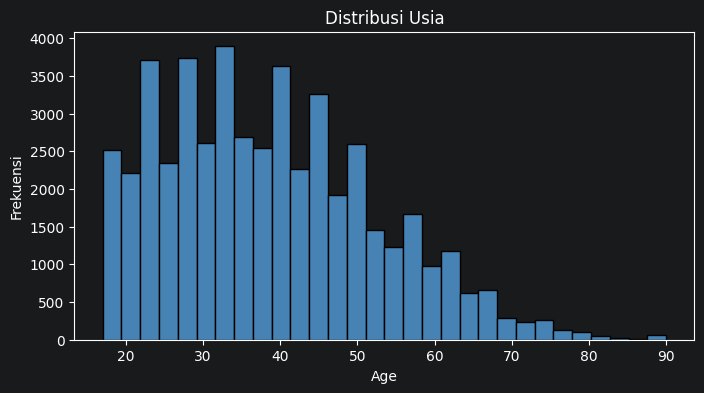

In [12]:
# Jawab 1.1 - Histrogram
plt.figure(figsize=(8,4))
plt.hist(df['age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribusi Usia')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()

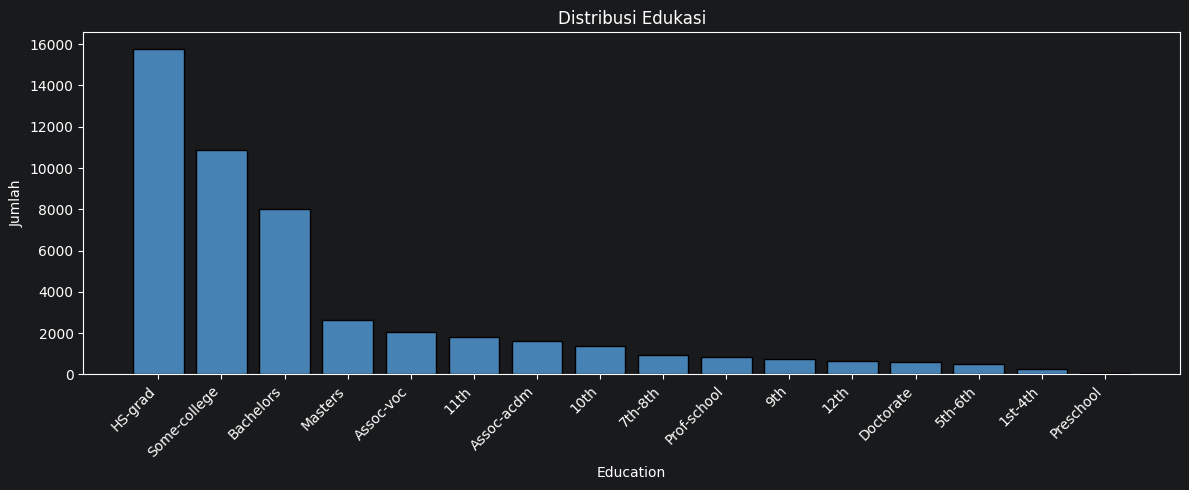

In [13]:
# Jawab 1.2 - Barchart
edu_counts = df['education'].value_counts()
plt.figure(figsize=(12, 5))
plt.bar(edu_counts.index, edu_counts.values, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Distribusi Edukasi')
plt.xlabel('Education')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

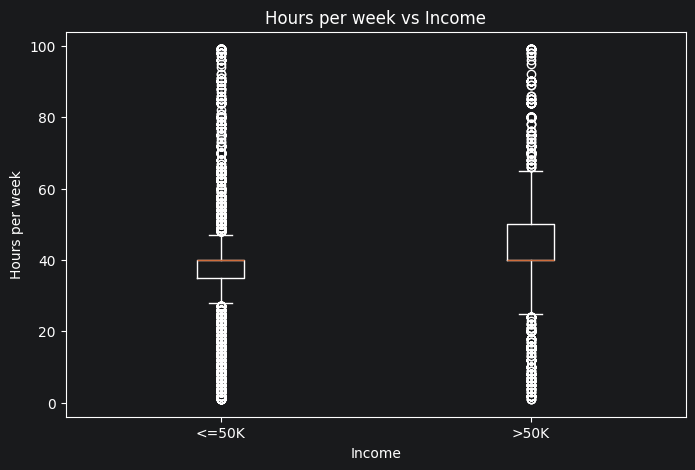

In [14]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(8, 5))
cats = df['income'].unique()
groups = [df[df['income']==cat]['hours-per-week'].values for cat in cats]
plt.boxplot(groups, tick_labels=cats)
plt.title('Hours per week vs Income')
plt.xlabel('Income')
plt.ylabel('Hours per week')
plt.show()

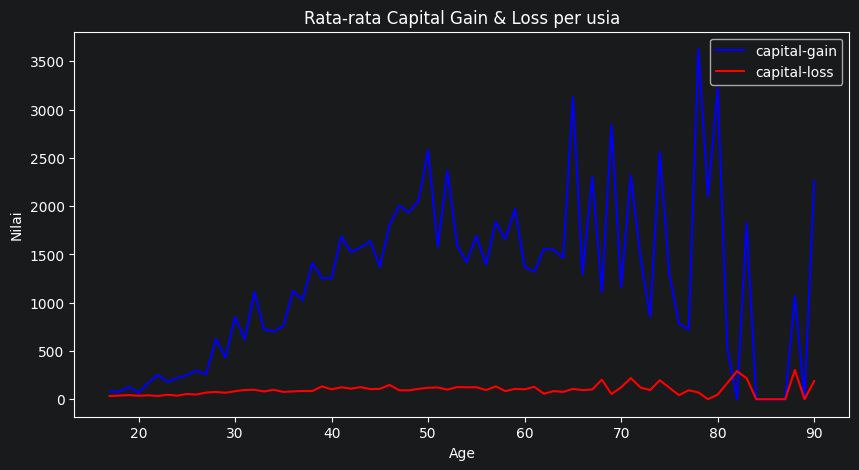

In [15]:
# Jawab 1.4 - Lineplot
age_group = df.groupby('age')[['capital-gain', 'capital-loss']].mean()
plt.figure(figsize=(10, 5))
plt.plot(age_group.index, age_group['capital-gain'], label='capital-gain', color='blue')
plt.plot(age_group.index, age_group['capital-loss'], label='capital-loss', color='red')
plt.title('Rata-rata Capital Gain & Loss per usia')
plt.xlabel('Age')
plt.ylabel('Nilai')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [16]:
# Jawab dengan komentar python


'''
1. Distribusi data 'age' bersifat right-skewed (condong ke kanan).
   Mayoritas penduduk berusia sekitar 25-45 tahun, dengan ekor panjang ke kanan (usia tua).

2. Jika terdapat missing value pada 'age', strategi yang tepat adalah menggunakan MEDIAN,
   karena data berdistribusi skewed (tidak normal). Median lebih robust terhadap outlier
   dan skewness dibanding mean.

3. Jumlah outlier dihitung dengan aturan IQR (Q1 - 1.5*IQR atau Q3 + 1.5*IQR).
   Berdasarkan boxplot, kategori <=50K cenderung memiliki lebih banyak outlier pada
   hours-per-week, namun kategori >50K juga menunjukkan outlier di sisi atas.
'''
# Hitung jumlah outlier per kategori income
for cat in df['income'].unique():
    subset = df[df['income'] == cat]['hours-per-week']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((subset < Q1 - 1.5*IQR) | (subset > Q3 + 1.5*IQR)).sum()
    print(f'Income {cat}: {n_outliers} outlier')


Income <=50K: 11706 outlier
Income >50K: 781 outlier


# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [17]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['income'] = df['income'].map({'>50K': 1, '<=50K': 0})

print(df[['sex', 'income']].head())
print('\nNilai unik sex:', df['sex'].unique())
print('Nilai unik income:', df['income'].unique())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0

Nilai unik sex: [1 0]
Nilai unik income: [0 1]


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

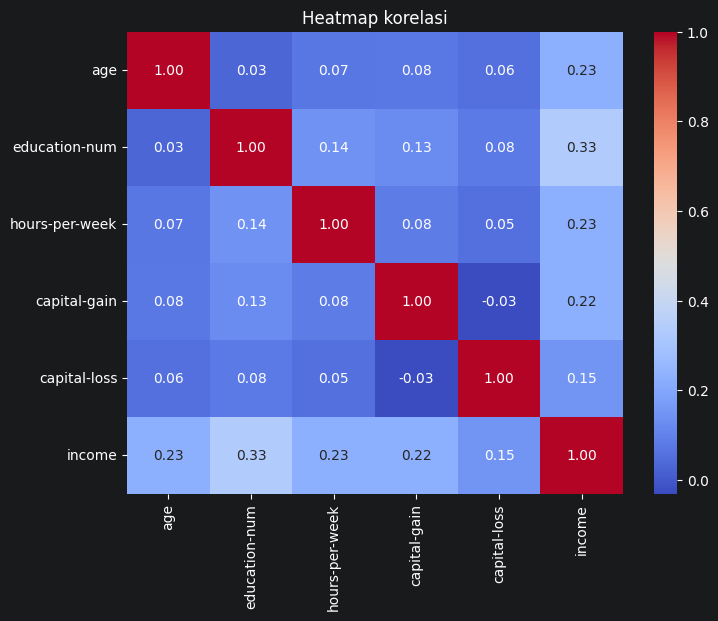

income            1.000000
education-num     0.332613
age               0.230369
hours-per-week    0.227687
capital-gain      0.223013
capital-loss      0.147554
Name: income, dtype: float64


In [18]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']
corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Heatmap korelasi')
plt.show()

print(corr_matrix['income'].sort_values(ascending=False))

In [19]:
# Hasil analisis jelaskan pada cell ini

'''
Interpretasi Korelasi terhadap 'income':
- education-num memiliki korelasi tertinggi dengan income (~0.33),
  artinya semakin tinggi pendidikan, cenderung income lebih besar.
- age juga berkorelasi positif (~0.24), usia lebih tua cenderung income lebih tinggi.
- hours-per-week berkorelasi positif lemah (~0.23), jam kerja lebih banyak cenderung income lebih tinggi.
- capital-gain berkorelasi positif dengan income (~0.22).
- capital-loss berkorelasi sangat rendah dengan income.
- Secara keseluruhan, tidak ada fitur dengan korelasi sangat kuat terhadap income.
'''

"\nInterpretasi Korelasi terhadap 'income':\n- education-num memiliki korelasi tertinggi dengan income (~0.33),\n  artinya semakin tinggi pendidikan, cenderung income lebih besar.\n- age juga berkorelasi positif (~0.24), usia lebih tua cenderung income lebih tinggi.\n- hours-per-week berkorelasi positif lemah (~0.23), jam kerja lebih banyak cenderung income lebih tinggi.\n- capital-gain berkorelasi positif dengan income (~0.22).\n- capital-loss berkorelasi sangat rendah dengan income.\n- Secara keseluruhan, tidak ada fitur dengan korelasi sangat kuat terhadap income.\n"

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [20]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


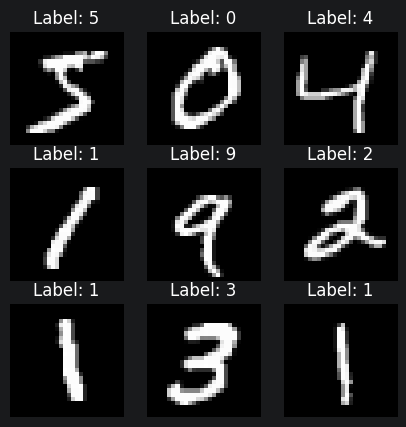

In [21]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Shape hasil upsampling: (10000, 32, 32)


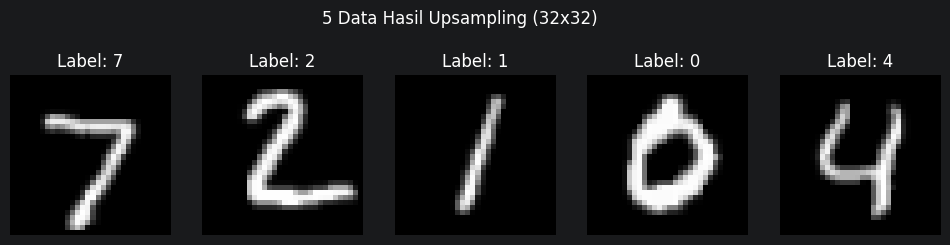

In [23]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

from PIL import Image

x_test_32 = np.zeros((X_test.shape[0], 32, 32), dtype=np.uint8)

for i in range(len(X_test)):
    img = Image.fromarray(X_test[i])
    img_resized = img.resize((32, 32), Image.BILINEAR)
    x_test_32[i] = np.array(img_resized)

print('Shape hasil upsampling:', x_test_32.shape)

plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test_32[i], cmap="gray")
    plt.title(f'Label: {y_test[i]}')
    plt.axis('off')
plt.suptitle('5 Data Hasil Upsampling (32x32)')
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [24]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

x_test_normalized = x_test_32 / 255.0

print('Min value setelah normalisasi:', x_test_normalized.min())
print('Max value setelah normalisasi:', x_test_normalized.max())
print('Shape:', x_test_normalized.shape)

Min value setelah normalisasi: 0.0
Max value setelah normalisasi: 1.0
Shape: (10000, 32, 32)


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [25]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

n_samples = x_test_normalized.shape[0]
n_features = 32 * 32

x_test_flat = np.zeros((n_samples, n_features))

for i in range(n_samples):
    x_test_flat[i] = x_test_normalized[i].flatten()

print('Shape setelah flatten:', x_test_flat.shape)
print('Contoh data pertama (10 piksel pertama):', x_test_flat[0][:10])

Shape setelah flatten: (10000, 1024)
Contoh data pertama (10 piksel pertama): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
